# Visual Exploration: Actors group

1. Overall response distribution

2. Counts and proportions by condition
    - Goal Type
    - Agency
    - Goal Type x Agency

Import libraries

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

Load data

In [19]:
responses = pd.read_csv("../../data/raw/counterfactual_responses_raw.csv")
metadata = pd.read_csv("../../data/raw/metadata_raw.csv")

Clean data

In [20]:
responses["Response"] = responses["Response"].str.strip()

responses = responses.rename(
    columns={"Partcipant_ID": "Participant_ID"}
)

Slice by focus: "actors" or "self-focus"

In [21]:
responses_focus = responses[responses["Focus"] == "I"].copy()

## 1. Overall response distribution

**Overall response distribution plot for Actors**

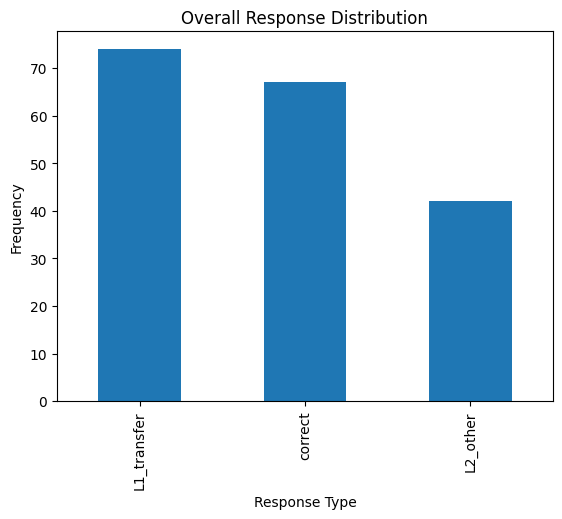

In [22]:
responses_focus["Response"].value_counts().plot(kind="bar")

plt.title("Overall Response Distribution") 
plt.xlabel("Response Type") 
plt.ylabel("Frequency")
plt.show()

Transfer keeps dominating the response landscape; however, compared to the overall group, the difference between those and correct responses isn't as high. 

**Overall response counts and proportions plot for Actors**

In [23]:
pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"]
)

Response,L1_transfer,L2_other,correct
Goal_Type,,,
goal_frequent,23,12,26
goal_non_frequent,25,13,23
no_goal,26,17,18


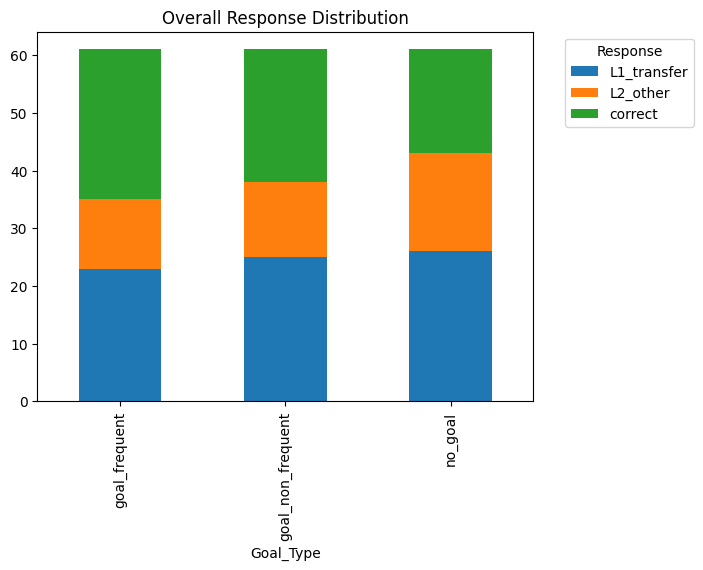

In [34]:
pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"]
).plot(kind = "bar", stacked = True)

plt.title("Overall Response Distribution")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## 2. Counts and Proportion by condition

**Responses by Goal Type:**

- Counts
- Proportions 
- Proportions plot

In [44]:
goal_response_counts = pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"],
    dropna=False,
    margins= True
)

goal_response_counts

Response,L1_transfer,L2_other,correct,NaN,All
Goal_Type,,,,,
goal_frequent,23,12,26,3,64
goal_non_frequent,25,13,23,3,64
no_goal,26,17,18,3,64
All,74,42,67,9,192


As a quick note re. null distribution, 9 of the original 11 null values are in the actors dataset. 

In [45]:
goal_response_props = pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"],
    normalize="index",
    dropna=False
)

goal_response_props

Response,L1_transfer,L2_other,correct,NaN
Goal_Type,,,,
goal_frequent,0.359375,0.187500,0.406250,0.046875
goal_non_frequent,0.390625,0.203125,0.359375,0.046875
no_goal,0.406250,0.265625,0.281250,0.046875


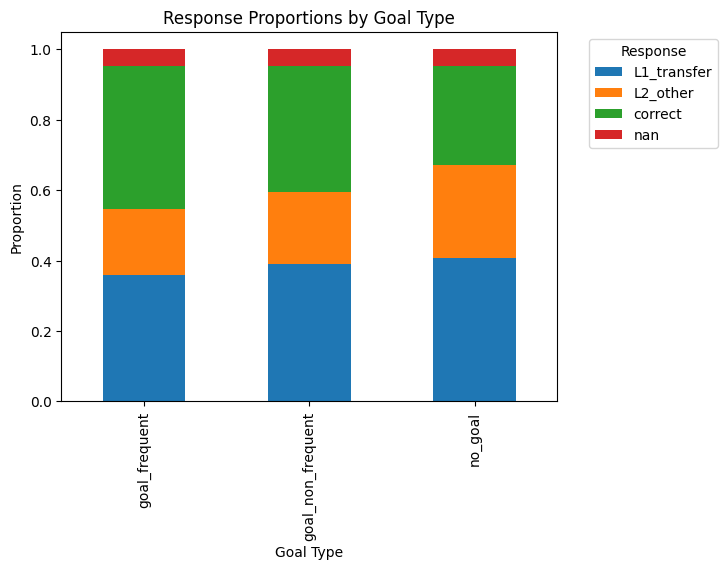

In [46]:
goal_response_props.plot(kind="bar", stacked=True)

plt.title("Response Proportions by Goal Type")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

The actors data split by goal type shows that:

- goal_frequent keeps showing to be the most supportive condition for succesful, or grammatically correct, resolution. 
- no_goal seems to produce fewer correct responses but higher alternative L2 approximations.
- There is a difference when it comes to goal_non_frequent though. For the overall group it seemed to be the most supportive condition for resolution by means of transfer; for actors, resolving by transfer isn't as high (0.49 vs. 0.39).
- Null response seems to be distributed fairly evenly among conditions.

**Responses by Agent:**

- Counts
- Proportions 
- Proportions plot

In [47]:
agent_response_counts = pd.crosstab(
    responses_focus["Agent"],
    responses_focus["Response"],
    margins=True,
    dropna=False
)

agent_response_counts

Response,L1_transfer,L2_other,correct,NaN,All
Agent,,,,,
0,40,30,37,7,114
1,34,12,30,2,78
All,74,42,67,9,192


In [48]:
agent_response_props = pd.crosstab(
    responses_focus["Agent"],
    responses_focus["Response"],
    normalize="index",
    dropna=False
)

agent_response_props

Response,L1_transfer,L2_other,correct,NaN
Agent,,,,
0,0.350877,0.263158,0.324561,0.061404
1,0.435897,0.153846,0.384615,0.025641


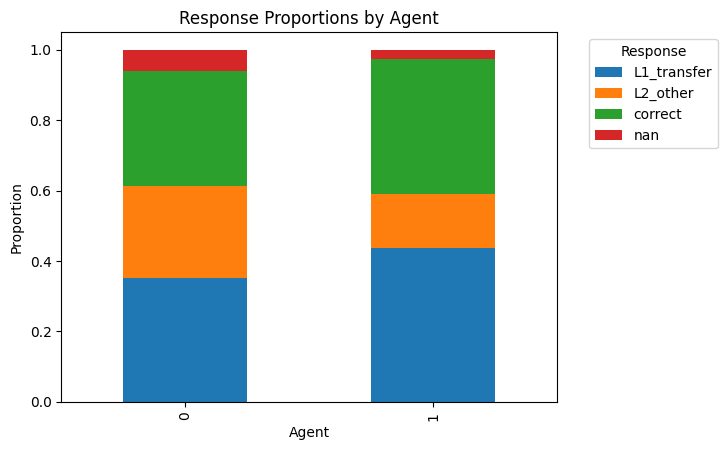

In [49]:
agent_response_props.plot(kind="bar", stacked=True)

plt.title("Response Proportions by Agent")
plt.xlabel("Agent")
plt.ylabel("Proportion")

plt.legend(
    title="Response",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

Again, it looks like agency seems to assist in how learners solve the problem:

- When there is an explicit Agent (Agent = 1) in the antecedent: 

    - learners keep commiting more strongly to a representation, either by means of a correct or a transfer response; yet, compared to the overall data, actors's resolution by transfer is slightly lower (0.50 vs 0.43) and correct resolution slightly higher (0.34 vs. 0.38).
    - there are fewer nan values

- When there isn't an explicit Agent (Agent = 0) in the antecedent: 

    - proportions for more L2 interpretations have hardly changed a bit and there keep being more L2 interpreations and fewer resolution responses either by means of a correct or a transfer response.
    - Again 7 of the 9 nan values fall here. This supports the idea that, though very small to start with, null distribution seems to be systematically patterned. 

**Responses by Goal Type and Agent:**

- Counts
- Proportions 
- Proportions plot

In [50]:
goal_agent_response_counts = pd.crosstab(
    [responses_focus["Goal_Type"], responses_focus["Agent"]],
    responses_focus["Response"],
    margins=True,
    dropna=False
)

goal_agent_response_counts

Response                 L1_transfer  L2_other  correct  NaN  All
Goal_Type         Agent                                          
goal_frequent     0               13         9       13    3   38
                  1               10         3       13    0   26
goal_non_frequent 0               12        10       14    2   38
                  1               13         3        9    1   26
no_goal           0               15        11       10    2   38
                  1               11         6        8    1   26
All                               74        42       67    9  192

In [51]:
goal_agent_response_props = pd.crosstab(
    [responses_focus["Goal_Type"], responses_focus["Agent"]],
    responses_focus["Response"],
    normalize="index",
    dropna=False
)

goal_agent_response_props

Response                 L1_transfer  L2_other   correct       NaN
Goal_Type         Agent                                           
goal_frequent     0         0.342105  0.236842  0.342105  0.078947
                  1         0.384615  0.115385  0.500000  0.000000
goal_non_frequent 0         0.315789  0.263158  0.368421  0.052632
                  1         0.500000  0.115385  0.346154  0.038462
no_goal           0         0.394737  0.289474  0.263158  0.052632
                  1         0.423077  0.230769  0.307692  0.038462

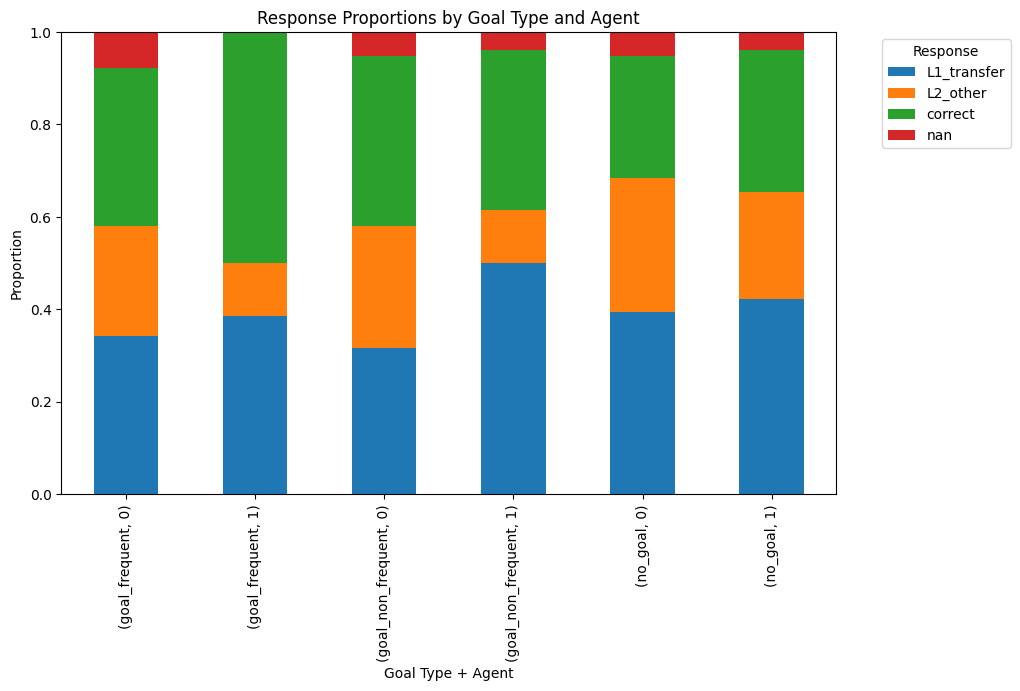

In [52]:
goal_agent_response_props.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Response Proportions by Goal Type and Agent")
plt.xlabel("Goal Type + Agent")
plt.ylabel("Proportion")

plt.legend(
    title="Response",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

- frequent_goal + explicit agent keeps showing the strongest successful counterfactual condiion as it shows the highest proportion of correct responses, the lowest proportion of L2 alternatives, no nulls, and while transfer is still expected and present, it is reduced.

- when it comes to non_frequent + explicit agent, transfer  resolution increases, correct resolution stagnates and L2 alternatives drop. this could look like committed failure as they construct the counterfactual representation but fail to resolve correctly. So, having a explicit agent (considering the items) could be forcing the encoding of responsability/ liability, increasing emotional salience and/ or causal commitment. What is shows is shows is that, for actors, full restructuring is costly. 

- lack of agency seems to weaken representational commitment.

- Again, absence of nulss in frequent_goal + explicit agency is meaningful. Missing data here is could show processing collapse, avoidance, overload,  hesitation and inability to commit to a structure ... the absence of nulls suggest that this condition could support cognitive completion.
